# 14-2: Introducción al Análisis de Supervivencia

**Curso:** Modelos de Análisis Estadístico (MAE) — Universidad de los Andes  
**Docente:** Prof. Alejandra Tabares  
**Semana:** 14

## 1. Conceptos Fundamentales del Análisis de Supervivencia

### 1.1 ¿Qué es el Análisis de Supervivencia?

El análisis de supervivencia modela el **tiempo hasta que ocurre un evento de interés** (muerte, falla, recaída, abandono, etc.). El desafío clave que lo distingue de la regresión ordinaria es la **censura**: con frecuencia no observamos el evento en todos los sujetos.

### 1.2 La Función de Supervivencia

Sea $T \ge 0$ el tiempo (aleatorio) del evento. La **función de supervivencia** es:

$$
S(t) = P(T > t), \quad t \ge 0
$$

- $S(0) = 1$ (todos están libres del evento al inicio)
- $S(\infty) = 0$ (eventualmente todos experimentan el evento)
- $S(t)$ es monótona no creciente y continua por la derecha

### 1.3 La Función de Riesgo

La **función de riesgo** (tasa de riesgo instantánea) es:

$$
h(t) = \lim_{\Delta t \to 0} \frac{P(t \le T < t + \Delta t \mid T \ge t)}{\Delta t} = \frac{f(t)}{S(t)}
$$

Relaciones clave:
$$
S(t) = \exp\!\left(-\int_0^t h(u)\,du\right) = \exp(-H(t))
$$

donde $H(t) = \int_0^t h(u)\,du$ es la **función de riesgo acumulado**.

### 1.4 Censura

| Tipo | Descripción | Ejemplo |
|---|---|---|
| **Censura por la derecha** | El tiempo del evento solo se sabe que supera el tiempo de observación | Paciente aún vivo al final del estudio |
| **Censura por la izquierda** | El tiempo del evento solo se sabe que precede al tiempo de observación | Sujeto ya había tenido el evento antes de ingresar al estudio |
| **Censura por intervalo** | El tiempo del evento cae dentro de un intervalo conocido | Visitas de seguimiento periódicas |

La **censura por la derecha** es la más común. Una observación $(t_i, \delta_i)$ registra:
- $t_i$ = tiempo observado (tiempo del evento si $\delta_i=1$, tiempo de censura si $\delta_i=0$)
- $\delta_i$ = indicador del evento ($1$ = evento observado, $0$ = censurado)

> **¿Por qué no ignorar las observaciones censuradas?** Hacerlo introduce **sesgo de selección**: los sujetos censurados pueden haber tenido tiempos de supervivencia más largos, por lo que eliminarlos subestima $S(t)$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(2024)
n = 200

# ── Simular datos de supervivencia con censura por la derecha ────────────────────────
# Dos grupos: tratamiento (group=1) y control (group=0)
group = np.random.binomial(1, 0.5, n)

# Tiempos de evento verdaderos de una distribución Weibull
# El grupo de tratamiento tiene mayor supervivencia (escala = 10 vs 6)
scale_true = np.where(group == 1, 10.0, 6.0)
shape_weibull = 1.5
T_true = scale_true * np.random.weibull(shape_weibull, n)

# Tiempos de censura de Uniform(5, 20) — independientes del tiempo del evento
C = np.random.uniform(5, 20, n)

# Tiempo observado e indicador de evento
T_obs = np.minimum(T_true, C)
delta = (T_true <= C).astype(int)   # 1 = evento observado

# Una covariable continua: edad (estandarizada)
age = np.random.normal(55, 10, n)
age_std = (age - age.mean()) / age.std()

df = pd.DataFrame({
    'time':    T_obs,
    'event':   delta,
    'group':   group,
    'age':     age,
    'age_std': age_std
})

print('Conjunto de datos de supervivencia simulado')
print('='*45)
print(f'n = {n} sujetos')
print(f'Eventos observados: {delta.sum()} ({100*delta.mean():.1f}%)')
print(f'Censurados:         {n - delta.sum()} ({100*(1-delta.mean()):.1f}%)')
print()
print(df.head(10).to_string(index=False))

Conjunto de datos de supervivencia simulado
n = 200 sujetos
Eventos observados: 164 (82.0%)
Censurados:         36 (18.0%)

    time  event  group       age   age_std
6.777428      1      1 52.072228 -0.343024
9.211833      0      1 68.504804  1.275301
2.122376      1      0 52.774692 -0.273843
0.145469      1      0 41.784036 -1.356233
9.909261      1      0 55.128207 -0.042062
9.914552      1      0 47.852224 -0.758621
6.185710      0      1 50.691939 -0.478958
2.232779      1      1 90.761341  3.467186
4.810758      1      0 54.201983 -0.133279
4.596943      1      0 37.399405 -1.788043


## 2. El Estimador de Kaplan-Meier

El estimador de **Kaplan-Meier (KM)** es un estimador de máxima verosimilitud no paramétrico de $S(t)$. Utiliza solo los tiempos de evento observados y tiene en cuenta correctamente las observaciones censuradas.

### Fórmula

Sean $t_1 < t_2 < \cdots < t_k$ los tiempos de **evento** distintos observados (no tiempos de censura). En cada $t_j$:

- $d_j$ = número de eventos (muertes) en $t_j$
- $n_j$ = número en riesgo justo antes de $t_j$ (que aún no han tenido el evento ni han sido censurados)

$$
\hat{S}(t) = \prod_{j:\, t_j \le t} \left(1 - \frac{d_j}{n_j}\right)
$$

### Propiedades

- Función escalonada que decrece solo en los tiempos de evento observados
- Las observaciones censuradas contribuyen al conjunto de riesgo $n_j$ pero no provocan una caída en $\hat{S}$
- La **fórmula de Greenwood** da la varianza: $\widehat{\text{Var}}[\hat{S}(t)] = \hat{S}(t)^2 \sum_{j:\,t_j \le t} \frac{d_j}{n_j(n_j - d_j)}$
- El IC al 95% se construye típicamente en la escala log o log-log para mejor cobertura cerca de 0 y 1

### Prueba Log-Rank

Para comparar $\hat{S}(t)$ entre dos grupos, la **prueba log-rank** utiliza:

$$
\chi^2 = \frac{\left(\sum_j (d_{1j} - E_{1j})\right)^2}{\sum_j V_{1j}} \sim \chi^2_1
$$

donde $E_{1j}$ es el número esperado de eventos en el grupo 1 en el tiempo $t_j$ bajo $H_0: S_1(t) = S_2(t)$.

lifelines disponible — usando KaplanMeierFitter
Prueba log-rank: chi2=33.802, p=0.0000


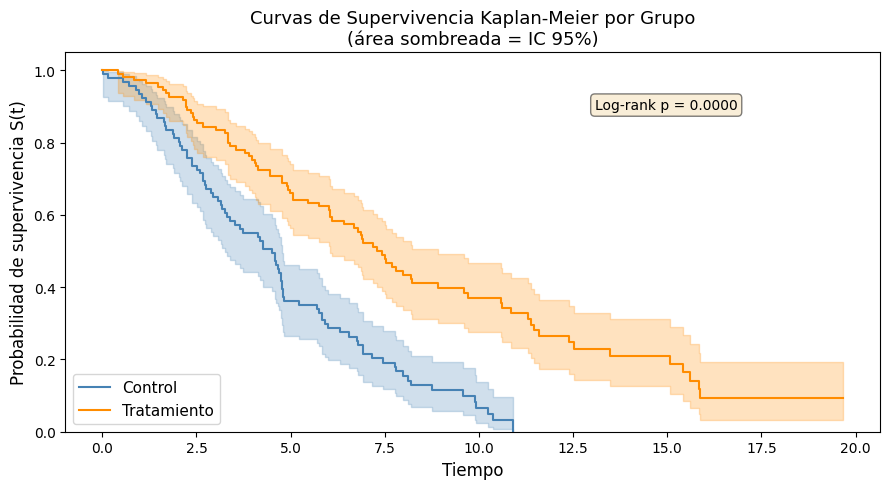

In [2]:
# ── Kaplan-Meier: intentar lifelines, usar implementación manual como alternativa ─────

def km_manual(times, events):
    """
    Estimador de Kaplan-Meier manual.
    Devuelve arreglos: t_unique (tiempos de evento), S_hat, lower_95, upper_95
    """
    data = pd.DataFrame({'t': times, 'd': events}).sort_values('t')
    t_unique = np.sort(np.unique(data.loc[data['d'] == 1, 't']))
    n_total = len(times)

    S = 1.0
    greenwood_sum = 0.0
    S_vals, lower_vals, upper_vals = [], [], []
    n_at_risk = n_total
    prev_t = -np.inf

    for t in t_unique:
        # Actualizar conjunto de riesgo: restar los que tienen tiempo observado < t
        n_at_risk -= np.sum((data['t'] < t) & (data['t'] > prev_t))
        d = np.sum((data['t'] == t) & (data['d'] == 1))
        if n_at_risk > 0 and d > 0:
            S *= (1 - d / n_at_risk)
            if n_at_risk > d:
                greenwood_sum += d / (n_at_risk * (n_at_risk - d))
        se = S * np.sqrt(greenwood_sum)
        S_vals.append(S)
        lower_vals.append(max(0, S - 1.96 * se))
        upper_vals.append(min(1, S + 1.96 * se))
        prev_t = t

    return t_unique, np.array(S_vals), np.array(lower_vals), np.array(upper_vals)


try:
    from lifelines import KaplanMeierFitter
    from lifelines.statistics import logrank_test
    USE_LIFELINES = True
    print('lifelines disponible — usando KaplanMeierFitter')
except ImportError:
    USE_LIFELINES = False
    print('lifelines no instalado — usando implementación KM manual')


fig, ax = plt.subplots(figsize=(9, 5))

colors = {0: 'steelblue', 1: 'darkorange'}
labels = {0: 'Control', 1: 'Tratamiento'}

if USE_LIFELINES:
    kmf = KaplanMeierFitter()
    for g in [0, 1]:
        mask = df['group'] == g
        kmf.fit(df.loc[mask, 'time'], df.loc[mask, 'event'], label=labels[g])
        kmf.plot_survival_function(ax=ax, ci_show=True, color=colors[g])

    # Prueba log-rank
    lr = logrank_test(df.loc[df['group']==0,'time'], df.loc[df['group']==1,'time'],
                      df.loc[df['group']==0,'event'], df.loc[df['group']==1,'event'])
    print(f'Prueba log-rank: chi2={lr.test_statistic:.3f}, p={lr.p_value:.4f}')
    ax.text(0.65, 0.85, f'Log-rank p = {lr.p_value:.4f}',
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
else:
    for g in [0, 1]:
        mask = df['group'] == g
        t_u, S_u, lo, hi = km_manual(df.loc[mask,'time'].values,
                                      df.loc[mask,'event'].values)
        ax.step(np.concatenate([[0], t_u]), np.concatenate([[1], S_u]),
                where='post', color=colors[g], label=labels[g])
        ax.fill_between(np.concatenate([[0], t_u]),
                         np.concatenate([[1], lo]),
                         np.concatenate([[1], hi]),
                         step='post', alpha=0.2, color=colors[g])

ax.set_xlabel('Tiempo', fontsize=12)
ax.set_ylabel('Probabilidad de supervivencia S(t)', fontsize=12)
ax.set_title('Curvas de Supervivencia Kaplan-Meier por Grupo\n(área sombreada = IC 95%)', fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 3. Modelo de Riesgos Proporcionales de Cox

El **modelo Cox PH** (Cox 1972) es el modelo de regresión más utilizado en el análisis de supervivencia. Es **semi-paramétrico**: el riesgo basal $h_0(t)$ se deja sin especificar, mientras que el efecto de las covariables entra de forma multiplicativa.

### Modelo

$$
h(t \mid \mathbf{x}) = h_0(t) \exp(\beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p)
$$

### Propiedad de Riesgos Proporcionales

El cociente de riesgos entre dos sujetos con covariables $\mathbf{x}$ y $\mathbf{x}^*$ es **constante en el tiempo**:

$$
\frac{h(t \mid \mathbf{x})}{h(t \mid \mathbf{x}^*)} = \exp\!\left(\boldsymbol{\beta}^\top(\mathbf{x} - \mathbf{x}^*)\right)
$$

### Interpretación — Razones de Riesgo

- $\hat{\text{HR}}_j = e^{\hat{\beta}_j}$: cambio multiplicativo en el riesgo por un aumento de una unidad en $x_j$, manteniendo los demás fijos
- $\text{HR} > 1$: mayor riesgo (evento más rápido, peor supervivencia)
- $\text{HR} < 1$: menor riesgo (evento más lento, mejor supervivencia)
- $\text{HR} = 1$: sin efecto

### Estimación por Verosimilitud Parcial

Cox propuso estimar $\boldsymbol{\beta}$ maximizando la **verosimilitud parcial**:

$$
L(\boldsymbol{\beta}) = \prod_{i:\,\delta_i=1} \frac{\exp(\mathbf{x}_i^\top \boldsymbol{\beta})}{\sum_{j \in \mathcal{R}(t_i)} \exp(\mathbf{x}_j^\top \boldsymbol{\beta})}
$$

donde $\mathcal{R}(t_i)$ es el **conjunto de riesgo** en el tiempo $t_i$ (todos los sujetos aún bajo observación). El riesgo basal $h_0(t)$ se cancela, lo que hace posible la estimación sin especificarlo.

In [3]:
# ── Modelo Cox PH ───────────────────────────────────────────────────────────────────────

try:
    from lifelines import CoxPHFitter
    USE_LIFELINES_COX = True
    print('Ajustando modelo Cox con lifelines.CoxPHFitter')
except ImportError:
    USE_LIFELINES_COX = False
    print('lifelines no disponible — usando statsmodels PHReg')


if USE_LIFELINES_COX:
    cox_df = df[['time', 'event', 'group', 'age_std']].copy()
    cph = CoxPHFitter()
    cph.fit(cox_df, duration_col='time', event_col='event')
    cph.print_summary()

    # Razones de riesgo con IC 95%
    hr_table = pd.DataFrame({
        'coef':      cph.params_,
        'HR':        np.exp(cph.params_),
        'HR_lower':  np.exp(cph.confidence_intervals_['95% lower-bound']),
        'HR_upper':  np.exp(cph.confidence_intervals_['95% upper-bound']),
        'p':         cph.summary['p']
    }).round(4)
    print('\nTabla de Razones de Riesgo')
    print('='*55)
    print(hr_table.to_string())

else:
    # Alternativa con statsmodels
    from statsmodels.duration.hazard_regression import PHReg
    endog  = df['time'].values
    status = df['event'].values
    exog   = df[['group', 'age_std']].values
    cox_sm = PHReg(endog, exog, status=status,
                   exog_names=['group', 'age_std']).fit()
    print(cox_sm.summary())

    hr_table = pd.DataFrame({
        'coef':  cox_sm.params,
        'HR':    np.exp(cox_sm.params),
        'p':     cox_sm.pvalues
    }, index=['group', 'age_std']).round(4)
    print('\nTabla de Razones de Riesgo')
    print(hr_table.to_string())

Ajustando modelo Cox con lifelines.CoxPHFitter


<lifelines.CoxPHFitter: fitted with 200 total observations, 36 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 200
number of events observed = 164
   partial log-likelihood = -722.31
         time fit was run = 2026-03-20 22:25:07 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
group     -0.97      0.38      0.17           -1.30           -0.63                0.27                0.53
age_std    0.10      1.11      0.08           -0.06            0.27                0.94                1.31

           cmp to     z      p  -log2(p)
covariate                               
group        0.00 -5.72 <0.005     26.45
age_std      0.00  1.27   0.20      2.29
---
Concordance = 0.61
Partial AIC = 1448.62
log-likelihood ratio test = 33.49 on 2 df
-log2(p) of ll-ratio test = 24.15


Tabla de Razones de Riesgo
             coef      HR  HR_lower  HR_upper       p
covariate                                            
group     -0.9655  0.3808    0.2735    0.5302  0.0000
age_std    0.1047  1.1103    0.9447    1.3050  0.2042


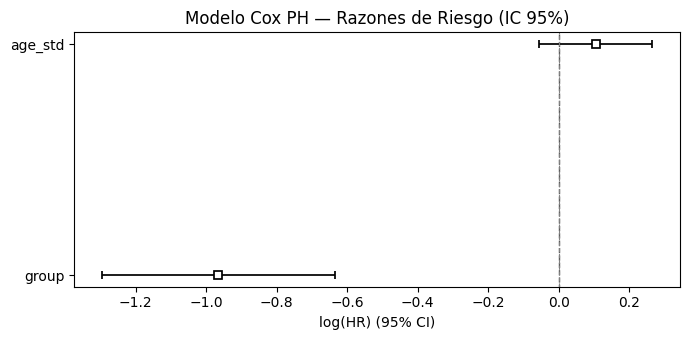

In [4]:
# ── Gráfico de bosque (forest plot) de razones de riesgo ──────────────────────────────

if USE_LIFELINES_COX:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    cph.plot(ax=ax)
    ax.set_title('Modelo Cox PH — Razones de Riesgo (IC 95%)', fontsize=12)
    ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
    plt.tight_layout()
    plt.show()
else:
    # Gráfico de bosque manual
    vars_plot = ['group', 'age_std']
    hr_vals   = np.exp(cox_sm.params)
    conf      = cox_sm.conf_int()
    hr_lo     = np.exp(conf[:, 0])
    hr_hi     = np.exp(conf[:, 1])

    fig, ax = plt.subplots(figsize=(7, 3))
    y_pos = np.arange(len(vars_plot))
    ax.errorbar(hr_vals, y_pos,
                xerr=[hr_vals - hr_lo, hr_hi - hr_vals],
                fmt='o', color='steelblue', ecolor='steelblue',
                capsize=5, markersize=8)
    ax.axvline(1, color='grey', linestyle='--', linewidth=0.9)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(vars_plot, fontsize=11)
    ax.set_xlabel('Razón de riesgo (escala log)', fontsize=11)
    ax.set_xscale('log')
    ax.set_title('Cox PH — Razones de Riesgo (IC 95%)', fontsize=12)
    plt.tight_layout()
    plt.show()

## 4. Verificación del Supuesto de Riesgos Proporcionales

El supuesto de RP — que las razones de riesgo son constantes en el tiempo — debe verificarse antes de confiar en los resultados del modelo Cox.

### Método 1: Gráfico Log-Log de Supervivencia

Bajo RP, las curvas KM transformadas log-log para dos grupos deben ser **paralelas** (distancia vertical constante):

$$
\ln(-\ln \hat{S}_g(t)) = \ln(-\ln S_0(t)) + \beta_g
$$

Las curvas no paralelas sugieren que el supuesto de RP es violado.

### Método 2: Residuos de Schoenfeld (prueba formal)

Los **residuos de Schoenfeld** para la covariable $j$ en el tiempo de evento $t_i$:

$$
r_{ij} = x_{ij} - \hat{E}[x_j \mid \mathcal{R}(t_i)]
$$

Si se cumple RP, los residuos de Schoenfeld son **no correlacionados con el tiempo**. Una correlación significativa (prueba de Grambsch-Therneau) indica efectos que varían en el tiempo.

### Método 3: Coeficientes que Varían en el Tiempo

Agregar una interacción $x_j \cdot g(t)$ (p. ej., $g(t) = \ln(t)$) al modelo. Un término de interacción significativo señala violación del RP.

### ¿Qué hacer cuando falla RP?

| Solución | Cuándo usarla |
|---|---|
| Estratificar por la variable que viola el supuesto | La variable es un factor de confusión no relevante |
| Agregar coeficiente que varía en el tiempo | Se desea cuantificar el efecto variable en el tiempo |
| Modelo de Tiempo de Falla Acelerado (AFT) | Alternativa paramétrica al Cox |
| Modelo paramétrico flexible (Royston-Parmar) | Se necesita un riesgo basal suavizado |


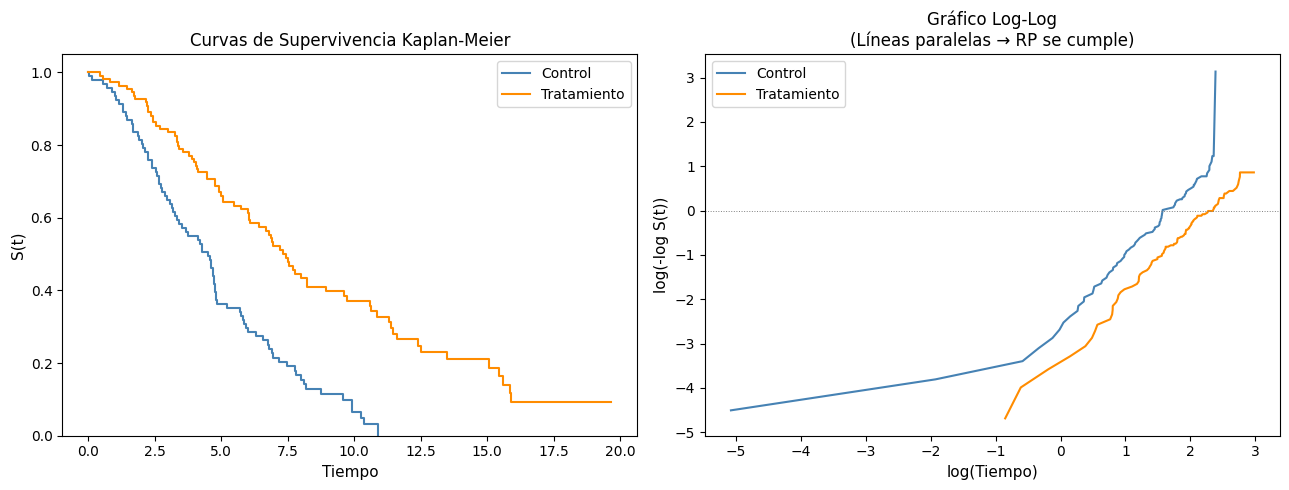


Interpretación:
  Si las líneas en el gráfico log-log son aproximadamente paralelas, el
  supuesto de riesgos proporcionales se ve respaldado para la variable grupo.

Prueba de residuos de Schoenfeld (lifelines):
         test_statistic         p  -log2(p)
age_std        1.945849  0.163035  2.616748
group          0.971870  0.324214  1.624980

  p > 0.05 para cada variable: sin evidencia de violación de RP


In [5]:
# ── Gráfico log-log para verificar el supuesto de RP ──────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

if USE_LIFELINES:
    kmf2 = KaplanMeierFitter()
    for g in [0, 1]:
        mask = df['group'] == g
        kmf2.fit(df.loc[mask, 'time'], df.loc[mask, 'event'], label=labels[g])
        # Gráfico KM estándar
        kmf2.plot_survival_function(ax=axes[0], ci_show=False, color=colors[g])
        # Gráfico log-log
        t_vals = kmf2.survival_function_.index.values[1:]
        S_vals = kmf2.survival_function_.iloc[1:, 0].values
        lls = np.log(-np.log(np.where(S_vals > 0, S_vals, 1e-10)))
        axes[1].plot(np.log(t_vals), lls, label=labels[g], color=colors[g])
else:
    for g in [0, 1]:
        mask = df['group'] == g
        t_u, S_u, lo, hi = km_manual(df.loc[mask,'time'].values,
                                      df.loc[mask,'event'].values)
        axes[0].step(np.concatenate([[0], t_u]), np.concatenate([[1], S_u]),
                     where='post', color=colors[g], label=labels[g])
        lls = np.log(-np.log(np.where(S_u > 0, S_u, 1e-10)))
        axes[1].plot(np.log(t_u), lls, label=labels[g], color=colors[g], marker='o', markersize=3)

axes[0].set_xlabel('Tiempo', fontsize=11)
axes[0].set_ylabel('S(t)', fontsize=11)
axes[0].set_title('Curvas de Supervivencia Kaplan-Meier', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].set_ylim(0, 1.05)

axes[1].set_xlabel('log(Tiempo)', fontsize=11)
axes[1].set_ylabel('log(-log S(t))', fontsize=11)
axes[1].set_title('Gráfico Log-Log\n(Líneas paralelas → RP se cumple)', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].axhline(0, color='grey', linestyle=':', linewidth=0.7)

plt.tight_layout()
plt.show()

print('\nInterpretación:')
print('  Si las líneas en el gráfico log-log son aproximadamente paralelas, el')
print('  supuesto de riesgos proporcionales se ve respaldado para la variable grupo.')

if USE_LIFELINES_COX:
    print('\nPrueba de residuos de Schoenfeld (lifelines):')
    try:
        from lifelines.statistics import proportional_hazard_test
        ph_test = proportional_hazard_test(cph, cox_df, time_transform='rank')
        print(ph_test.summary.to_string())
        print('\n  p > 0.05 para cada variable: sin evidencia de violación de RP')
    except Exception as e:
        print(f'  No se pudo ejecutar la prueba de RP: {e}')